In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxudong/Repositories/ESP/our_codes


In [ ]:
df = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "combdata.pkl"))

In [3]:
df

,complex_name,wei_score,if_right,enzyme,substrate,cc,substrate_cc,scores
2669,CYP72A66v2_ABA_C14,0.530,1,CYP72A66v2,ABA,C14,ABAC14,0.297941
2670,CYP72A7_ABA_C14,0.513,1,CYP72A7,ABA,C14,ABAC14,0.103160
2671,CYP72A62v2_ABA_C14,0.487,1,CYP72A62v2,ABA,C14,ABAC14,0.223932
2673,CYP707A1_ABA_C14,0.418,1,CYP707A1,ABA,C14,ABAC14,0.015169
2674,CYP72A475_ABA_C14,0.451,1,CYP72A475,ABA,C14,ABAC14,0.101858
...,...,...,...,...,...,...,...,...
75056,CYP72A610_AHT_C8,0.300,1,CYP72A610,AHT,C8,AHTC8,0.056422
75057,CYP74L1_AHT_C8,0.249,1,CYP74L1,AHT,C8,AHTC8,0.040597
75058,CYP79A12_AHT_C8,0.248,1,CYP79A12,AHT,C8,AHTC8,0.158764
75059,CYP71D12_AHT_C8,0.229,1,CYP71D12,AHT,C8,AHTC8,0.045258


In [ ]:
df1know = (0) / 100 * df[df["if_right"] == 2]["wei_score"] + (100) / 100 * df[
    df["if_right"] == 2
]["scores"]
df1unknow = (0) / 100 * df[df["if_right"] == 1]["wei_score"] + (100) / 100 * df[
    df["if_right"] == 1
]["scores"]
print((df1know).mean())
print((df1unknow).mean())

0.6629789085225447
0.2465002113477478


In [ ]:
df1know = (100) / 100 * df[df["if_right"] == 2]["wei_score"] + (0) / 100 * df[
    df["if_right"] == 2
]["scores"]
df1unknow = (100) / 100 * df[df["if_right"] == 1]["wei_score"] + (0) / 100 * df[
    df["if_right"] == 1
]["scores"]
print((df1know).mean())
print((df1unknow).mean())

0.4196684210526315
0.3142477105062325


In [ ]:
df1know = (76) / 100 * df[df["if_right"] == 2]["wei_score"] + (100 - 76) / 100 * df[
    df["if_right"] == 2
]["scores"]
df1unknow = (76) / 100 * df[df["if_right"] == 1]["wei_score"] + (100 - 76) / 100 * df[
    df["if_right"] == 1
]["scores"]
print((df1know).mean())
print((df1unknow).mean())

0.4780629340481742
0.2979883093622009


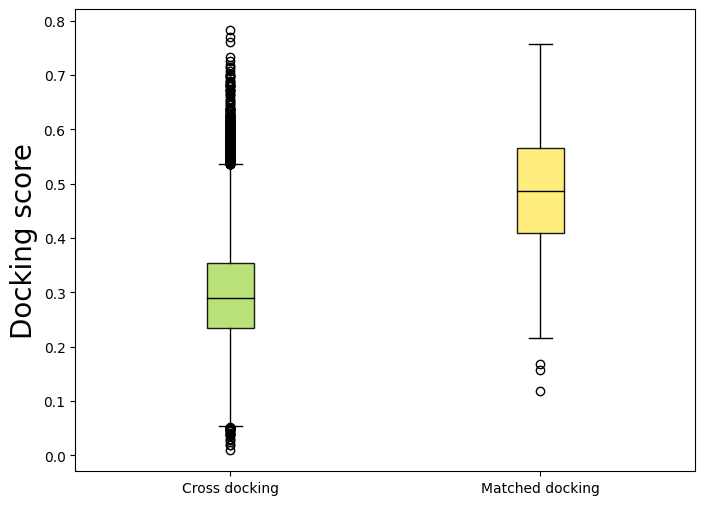

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))
cmap = cm.Set3
box = plt.boxplot([df1unknow, df1know], patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(cmap((i + 1) / (2)))
    patch.set_alpha(0.9)


for median in box["medians"]:
    median.set_color("black")
plt.ylabel("Docking score", fontsize=20)
plt.xticks([1, 2], ["Cross docking", "Matched docking"])
plt.show()